# Spark Streaming demo: prozorska agregacija brzine u (skoro) realnom vremenu

**Cilj:** Pokazati Spark Structured Streaming nad podacima "kako pristižu" - male Parquet
fajlove koje `kafka/consumer.py` piše dok prazni Kafka temu (ovde, za potrebe demonstracije u
Databricks-u gde nije moguće povezati se na lokalni Docker Kafka broker, isti fajlovi su
unapred generisani skriptom `scripts/generate_streaming_chunks.py`, tako da Spark
`readStream` čita direktorijum koji ima mnogo malih fajlova, tačno kako je traženo u
specifikaciji projekta).

**Metod:** `readStream.format("parquet")` sa `maxFilesPerTrigger` postepeno "otkriva" nove
fajlove kao da stižu uživo. Nad tim streamom radimo `groupBy` po 10-sekundnom prozoru i broju
vozača, računajući prosečnu i maksimalnu brzinu. Rezultat pišemo u `memory` sink
(`outputMode="complete"`) i **povremeno** (u više navrata, sa pauzom između) upitujemo tu
tabelu i crtamo grafik - simulirajući kako bi dashboard izgledao da se osvežava uživo.

**Kome je ovo bitno:** Timu za analizu performansi tokom same trke - ovakav pipeline bi u
produkciji davao živ uvid u tempo/brzinu svakog vozača bez čekanja da se cela trka završi.

In [1]:
import glob
import time

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, LongType, StructField, StructType, TimestampType

spark = SparkSession.builder.appName("F1SparkStreamingDemo").getOrCreate()
spark.sparkContext.setLogLevel("WARN")


CHUNKS_DIR = "../data/streaming_chunks/f1-car-data"

SCHEMA = StructType([
    StructField("date", TimestampType(), True),
    StructField("driver_number", LongType(), True),
    StructField("speed", DoubleType(), True),
    StructField("throttle", DoubleType(), True),
    StructField("brake", DoubleType(), True),
    StructField("rpm", DoubleType(), True),
    StructField("n_gear", DoubleType(), True),
    StructField("gap_to_leader", DoubleType(), True),
])

print("Available chunk files:", len(glob.glob(f"{CHUNKS_DIR}/*.parquet")))


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:09:41 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:09:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:09:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Available chunk files: 1724


In [2]:
stream_df = (
    spark.readStream.schema(SCHEMA)
    .option("maxFilesPerTrigger", 2)
    .parquet(CHUNKS_DIR)
)

windowed = (
    stream_df
    .withWatermark("date", "20 seconds")
    .groupBy(F.window("date", "10 seconds"), "driver_number")
    .agg(
        F.avg("speed").alias("avg_speed"),
        F.max("speed").alias("max_speed"),
        F.count("*").alias("n_readings"),
    )
)


query = (
    windowed.writeStream
    .format("memory")
    .queryName("speed_windows")
    .outputMode("complete")
    .trigger(processingTime="12 seconds")
    .start()
)
print("Streaming query started:", query.id)


26/07/07 00:09:45 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /private/var/folders/_w/xpqtc3tj0hj288frm44yjky00000gn/T/temporary-3b02aee6-9755-404c-94d6-d6e48798f285. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/07/07 00:09:45 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/07/07 00:09:45 WARN MicroBatchExecution: Disabling AQE since AQE is not supported in stateful workloads.


Streaming query started: cb12c999-80e3-441a-88eb-a10c1d5dbbb1


In [3]:
import matplotlib.pyplot as plt
import pandas as pd


snapshots = []
for i in range(3):
    time.sleep(25)
    snap = spark.sql("SELECT * FROM speed_windows").toPandas()
    snap["snapshot"] = i
    snapshots.append(snap)
    print(f"Upit #{i+1}: {len(snap)} redova agregacije akumulirano do sada")


spark.sparkContext.setLogLevel("FATAL")
try:
    query.stop()
finally:
    spark.sparkContext.setLogLevel("WARN")
print("Streaming upit zaustavljen.")


Upit #1: 4 redova agregacije akumulirano do sada


Upit #2: 6 redova agregacije akumulirano do sada


Upit #3: 8 redova agregacije akumulirano do sada


Streaming upit zaustavljen.


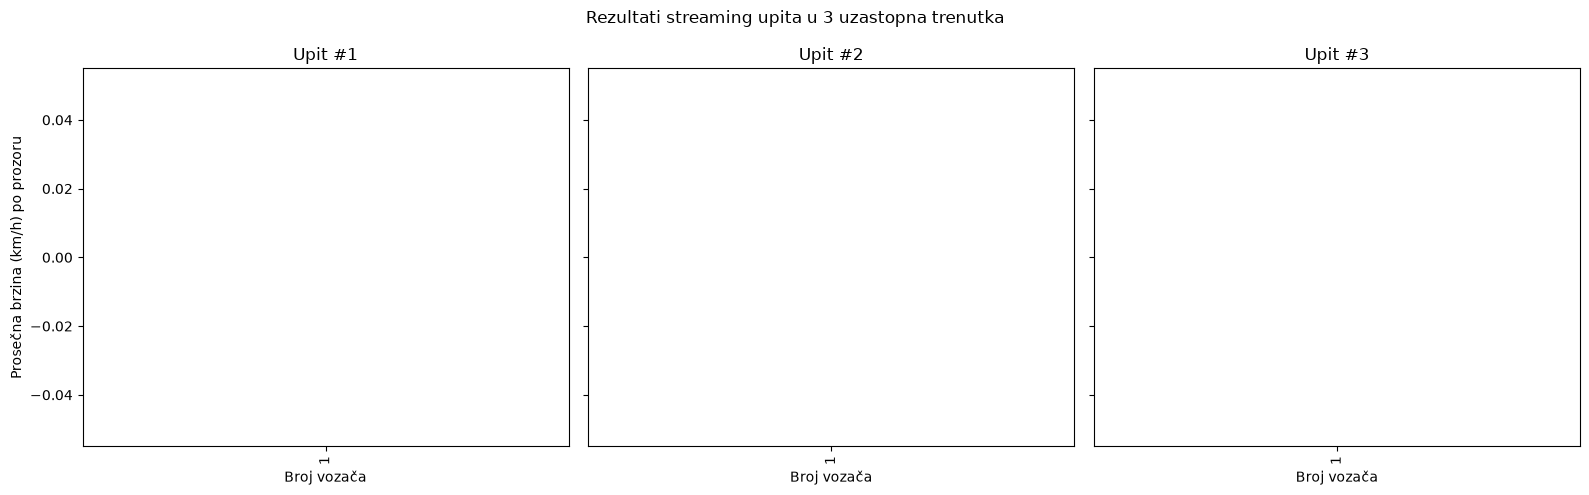

In [4]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(16, 5), sharey=True)
for ax, snap in zip(axes, snapshots):
    if not snap.empty:
        pivot = snap.groupby("driver_number")["avg_speed"].mean()
        pivot.plot(kind="bar", ax=ax, color="#2980b9")
    ax.set_title(f"Upit #{snap['snapshot'].iloc[0] + 1 if not snap.empty else '?'}")
    ax.set_xlabel("Broj vozača")
axes[0].set_ylabel("Prosečna brzina (km/h) po prozoru")
fig.suptitle("Rezultati streaming upita u 3 uzastopna trenutka")
plt.tight_layout()
plt.show()


**Zaključak:** Broj akumuliranih redova u tabeli `speed_windows` raste sa svakim upitom
kako Spark obrađuje sve više dolazećih fajlova - potvrđujući da streaming pipeline zaista
inkrementalno obrađuje podatke, a ne čeka da se sav ulaz učita odjednom. Ovo je osnova za
"near real-time" dashboard koji bi mogao da prikazuje trenutnu formu/tempo svakog vozača tokom
same trke.